# COMP0005 - GROUP COURSEWORK
# Experimental Evaluation of Search Data Structures and Algorithms

The cell below defines **AbstractSearchInterface**, an interface to support basic insert/search operations; you will need to implement this three times, to realise your three search data structures of choice among: (1) *2-3 Tree*, (2) *AVL Tree*, (3) *LLRB BST*; (4) *B-Tree*; and (5) *Scapegoat Tree*. <br><br>**Do NOT modify the next cell** - use the dedicated cells further below for your implementation instead. <br>

In [136]:
# DO NOT MODIFY THIS CELL

from abc import ABC, abstractmethod  

class AbstractSearchInterface(ABC):
    '''
    Abstract class to support search/insert operations (plus underlying data structure)
    
    '''
        
    @abstractmethod
    def insertElement(self, element):     
        '''
        Insert an element in a search tree
            Parameters:
                    element: string to be inserted in the search tree (string)

            Returns:
                    "True" after successful insertion, "False" if element is already present (bool)
        '''
        
        pass 
    

    @abstractmethod
    def searchElement(self, element):
        '''
        Search for an element in a search tree
            Parameters:
                    element: string to be searched in the search tree (string)

            Returns:
                    "True" if element is found, "False" otherwise (bool)
        '''

        pass

Use the cell below to define any auxiliary data structure and python function you may need. Leave the implementation of the main API to the next code cells instead.

In [137]:
# ADD AUXILIARY DATA STRUCTURE DEFINITIONS AND HELPER CODE HERE

class TwoThreeNode:
    def __init__(self, vals, parent=None, children=None):
        self.vals = vals
        self.parent = parent
        self.children = children if children is not None else []

    def is_two_node(self):
        return len(self.vals) == 1
    
    def is_leaf(self):
        return len(self.children) == 0

class AVLNode:
    def __init__(self, element, right = None, left = None):
        self.element = element
        self.right = right
        self.left = left
        self.height = 1
        
def AVLGetHeight(node):
    if node is None:
        return 0
    return node.height

def AVLGetBalance(node):
    return AVLGetHeight(node.right) - AVLGetHeight(node.left)

class Node:
    def __init__(self, element):
        self.element = element
        self.left = None
        self.right = None
        

Use the cell below to implement the requested API by means of **2-3 Tree** (if among your chosen data structure).

In [138]:
class TwoThreeTree(AbstractSearchInterface):

    def __init__(self):
        super().__init__()
        self.root = None
        
    def insertElement(self, element):
        # If tree is empty create a root
        if not self.root:
            self.root = TwoThreeNode([element])
            return True
        
        # Search for insertion spot
        node = self._findNode(element)
        if not node:
            return False

        #Insert in node
        if element > node.vals[-1]:
            node.vals.append(element)
        elif element < node.vals[0]:
            node.vals.insert(0, element)
        else:
            node.vals.insert(1, element)

        # Bubble up if more than 3 keys
        while node and len(node.vals) == 3:
            if not node.parent:
                self.root = TwoThreeNode([node.vals.pop(1)])
            elif node.vals[1] < node.parent.vals[0]:
                node.parent.vals.insert(0, node.vals.pop(1))
            elif node.vals[1] > node.parent.vals[-1]:
                node.parent.vals.append(node.vals.pop(1))
            else:
                node.parent.vals.insert(1, node.vals.pop(1))

            # Split the child nodes
            parent = node.parent if node.parent else self.root
            sub_children = [node.children[:2], node.children[2:]] if node.children else [[], []]
            children = [TwoThreeNode([node.vals[0]], parent=parent, children=sub_children[0]), 
                        TwoThreeNode([node.vals[1]], parent=parent, children=sub_children[1])]
            
            # Reconfigure parent/children relationships
            for i in range(2):
                for child in sub_children[i]:
                    child.parent = children[i]
            
            if parent is self.root and not parent.children:
                parent.children = children
            else:
                node_index = parent.children.index(node)
                parent.children = parent.children[:node_index] + children + parent.children[node_index + 1:]
    
            node = node.parent

        return True
    
    # findNode only returns None if the element is in the tree already
    def searchElement(self, element):
        if not self.root: return False
        return self._findNode(element) == None
    
    # Returns the node to insert an element, if it is already in the tree returns None 
    def _findNode(self, element):    
        node = self.root
        while True:
            # Check if the element is in this node
            if element in node.vals:
                return None
            # Return insertion spot
            if node.is_leaf():
                return node   
            # 2-node: only 2 children, 1 key
            if node.is_two_node():
                if element > node.vals[0]:
                    node = node.children[1]
                else:
                    node = node.children[0]
            # 3-node: 3 children, 2 keys
            else:
                if element > node.vals[1]:
                    node = node.children[2]
                elif element < node.vals[0]:
                    node = node.children[0]
                else:
                    node = node.children[1]

Use the cell below to implement the requested API by means of **AVL Tree** (if among your chosen data structure).

In [139]:
class AVLTree(AbstractSearchInterface):

    def __init__(self):
        self.root = None

    def _rotateLeft(self, node):
        newNode = node.right
        temp = newNode.left
        newNode.left = node
        node.right = temp
        node.height = 1 + max(AVLGetHeight(node.left), AVLGetHeight(node.right))
        newNode.height = 1 + max(AVLGetHeight(newNode.left), AVLGetHeight(newNode.right))
        return newNode
    
    def _rotateRight(self, node):
        newNode = node.left
        temp = newNode.right
        newNode.right = node
        node.left = temp
        node.height = 1 + max(AVLGetHeight(node.left), AVLGetHeight(node.right))
        newNode.height = 1 + max(AVLGetHeight(newNode.left), AVLGetHeight(newNode.right))
        return newNode

    def insertElementHelper(self, node, element):
        if node is None:
            return AVLNode(element), True

        if element > node.element:
            node.right, inserted = self.insertElementHelper(node.right, element)
        elif element < node.element:
            node.left, inserted = self.insertElementHelper(node.left, element)
        else:
            return node, False  

        node.height = 1 + max(AVLGetHeight(node.left), AVLGetHeight(node.right))
        balance = AVLGetBalance(node)
        
        # RR
        if balance > 1 and AVLGetBalance(node.right) >= 0:
            node = self._rotateLeft(node)
        # LL
        elif balance < -1 and AVLGetBalance(node.left) <= 0:
            node = self._rotateRight(node)
        # RL
        elif balance > 1 and AVLGetBalance(node.right) < 0:
            node.right = self._rotateRight(node.right)
            node = self._rotateLeft(node)
        # LR
        elif balance < -1 and AVLGetBalance(node.left) > 0:
            node.left = self._rotateLeft(node.left)
            node = self._rotateRight(node)

        return node, inserted

    def insertElement(self, element):
        self.root, inserted = self.insertElementHelper(self.root, element)
        return inserted

    def searchElement(self, element):
        node = self.root
        while node is not None:
            if element > node.element:
                node = node.right
            elif element < node.element:
                node = node.left
            else:
                return True
        return False

Use the cell below to implement the requested API by means of **LLRB BST** (if among your chosen data structure).

In [140]:
class LLRBBST(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found  

Use the cell below to implement the requested API by means of **B-Tree** (if among your chosen data structure).

In [141]:
class BTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found

Use the cell below to implement the requested API by means of **Scapegoat Tree** (if among your chosen data structure).

In [142]:
import math
class ScapegoatTree(AbstractSearchInterface):

    def __init__(self, alpha=2/3):
        self.root = None
        self.n = 0
        self.max_size = 0
        self.alpha = alpha
        
    def insertElement(self, element):
        path = []
        parent = None
        node = self.root

        while node is not None:
            if element == node.element:
                return False
            path.append(node)
            parent = node
            if element < node.element:
                node = node.left
            else:
                node = node.right

        new_node = Node(element)

        if parent is None:
            self.root = new_node
        else:
            if element < parent.element:
                parent.left = new_node
            else:
                parent.right = new_node

        self.n += 1
        self.max_size = max(self.max_size, self.n)

        depth = len(path)
        allowed = math.log(self.n) / math.log(1 / self.alpha)
        if depth > allowed:
            self._find_and_rebuild(path)

        return True
    
    def searchElement(self, element):  
        node = self.root
        while node is not None:
            if element == node.element:
                return True
            if element < node.element:
                node = node.left
            else:
                node = node.right
        return False

    # helper functions
    def _size(self, node):
        if node is None:
            return 0
        return 1 + self._size(node.left) + self._size(node.right)

    def _in_order_traversal(self, node, array):
        if node:
            self._in_order_traversal(node.left, array)
            array.append(node.element)
            self._in_order_traversal(node.right, array)   

    def _build_balanced(self, array, min, max):
        if min > max:
            return None
        avg = (min + max) // 2
        node = Node(array[avg])
        node.left = self._build_balanced(array, min, avg - 1)
        node.right = self._build_balanced(array, avg + 1, max)
        return node

    def _find_and_rebuild(self, path):
        for i in range(len(path) - 1, -1, -1):
            scapegoat = path[i]
            left_size = self._size(scapegoat.left)
            right_size = self._size(scapegoat.right)
            total = left_size + right_size + 1

            if max(left_size, right_size) > self.alpha * total:
                parent = path[i - 1] if i > 0 else None

                nodes = []
                self._in_order_traversal(scapegoat, nodes)
                new_subtree = self._build_balanced(nodes, 0, len(nodes) - 1)

                if parent is None:
                    self.root = new_subtree
                else:
                    if parent.left == scapegoat:
                        parent.left = new_subtree
                    else:
                        parent.right = new_subtree

                return

Use the cell below to implement the **synthetic data generator** needed by your experimental framework (be mindful of code readability and reusability).

In [143]:
import string
import random

class TestDataGenerator():
    '''
    A class to represent a synthetic data generator.

    ...

    Attributes
    ----------
    
    seed : int
        Random seed for reproducible results

    Methods
    -------
    
    generate_random_strings(count, length)
        Generate random strings in no particular order
    
    generate_sorted_strings(count, length)
        Generate strings in alphabetical order
    
    generate_nearly_sorted_strings(count, length, swap_fraction)
        Generate mostly sorted strings with some swaps
    
    generate_strings_with_duplicates(count, length, duplicate_fraction)
        Generate strings with some duplicates
    
    generate_search_hits(inserted_strings, count)
        Generate search targets that exist in the data
    
    generate_search_misses(inserted_strings, count, length)
        Generate search targets that do not exist in the data

    '''
    
    def __init__(self, seed=27):
        random.seed(seed)

    '''notes:
    -since methods are called internally, seed not completely consistent depending on order that methods are called
    -low lengths and high counts for random strings might produce duplicates
    '''
    # Insert test methods
    #Method 1: Random order
    def generate_random_strings(self, count, min_length=4, max_length=16):
        strings = []
        for i in range(count):
            l = random.randint(min_length, max_length)
            s = ''.join(random.choices(string.ascii_lowercase, k=l))
            strings.append(s)
        return strings
    
    #Method 2: Sorted (alphabetical) order
    def generate_sorted_strings(self, count):
        strings = self.generate_random_strings(count)
        strings.sort()
        return strings
    
    #Method 3: Nearly sorted (mostly sorted with ~5% swaps)
    def generate_nearly_sorted_strings(self, count, swap_fraction=0.2):
        strings = self.generate_sorted_strings(count)
        num_swaps = int(count * swap_fraction)
        for i in range(num_swaps):
            idx1 = random.randint(0, count - 1)
            idx2 = random.randint(0, count - 1)
            strings[idx1], strings[idx2] = strings[idx2], strings[idx1]
        return strings
    
    #Method 4: Strings with duplicates
    def generate_strings_with_duplicates(self, count, duplicate_fraction=0.4):
        unique_count = int(count * (1 - duplicate_fraction))
        unique_strings = self.generate_random_strings(unique_count)
        duplicates = random.choices(unique_strings, k=count - unique_count)
        result = unique_strings + duplicates
        random.shuffle(result)
        return result
    
    # Search test methods
    #Method 5: Search targets to be found
    def generate_search_hits(self, inserted_strings, count):
        return random.choices(inserted_strings, k=count)
    
    #Method 6: Search targets not to be found
    def generate_search_misses(self, inserted_strings, count, length=8):
        inserted_set = set(inserted_strings)
        misses = []
        while len(misses) < count:
            s = ''.join(random.choices(string.ascii_lowercase, k=length))
            if s not in inserted_set:
                misses.append(s)
        return misses
        

Use the cell below to implement the requested **experimental framework** (be mindful of code readability and reusability).

In [144]:
import timeit
import matplotlib.pyplot as plt

class ExperimentalFramework():
    '''
    A class to represent an experimental framework.

    ...

    Attributes
    ----------
    
    data_generator: TestDataGenerator instance used to generate data for testing
    sizes: different sizes of data to test trees on

    Methods
    -------
    
    time_insert: times how long inserting different length string arrays take for a specific tree 
            using a specific data generation method

    time_search: generates a ranodom array of string for each size and 
            times how long it takes to search in a specific tree og different sizes 
            uses a data generator method to genrate the strings to search for in the tree

    plot_comparison: takes results of all 3 trees timings for one function and plots them in a graph with a specified title  

    '''
    
    def __init__(self):
        self.data_generator = TestDataGenerator()
        self.sizes = [10**i for i in range(1,6)]

    def time_insert(self, tree_class, data_generator_method):
        times = []
        for size in self.sizes:
            data = data_generator_method(count=size)
            tree = tree_class()
            time = timeit.timeit(lambda: [tree.insertElement(e) for e in data], number=1)
            times.append(time)
        return times
    
    def time_search(self, tree_class, data_generator_method):
        times = []
        for size in self.sizes:
            strings = self.data_generator.generate_random_strings(count=size)
            tree = tree_class()
            
            inserted_strings = []
            for string in strings:
                if tree.insertElement(string):
                    inserted_strings.append(string)
            
            strings_to_search = data_generator_method(count=size, inserted_strings=inserted_strings)
            time = timeit.timeit(lambda: [tree.searchElement(e) for e in strings_to_search], number=1)
            times.append(time)

        return times

    
    def plot_comparison(self, results, title):
        for tree_name, times in results.items():
            plt.plot(self.sizes, times, label=tree_name)
        plt.xlabel("Dataset size")
        plt.ylabel("Time (s)")
        plt.title(title)
        plt.legend()
        plt.show()
    

Use the cell below to illustrate the python code you used to **fully evaluate** your three chosen search data structures and algortihms. The code below should illustrate, for example, how you made used of the **TestDataGenerator** class to generate test data of various size and properties; how you instatiated the **ExperimentalFramework** class to  evaluate each data structure using such data, collect information about their execution time, plot results, etc. Any results you illustrate in the companion PDF report should have been generated using the code below.

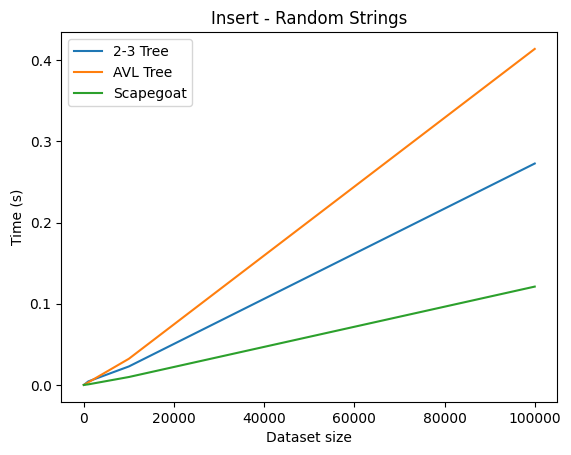

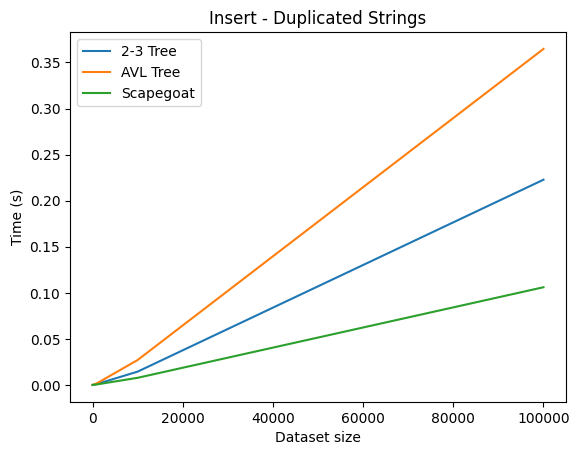

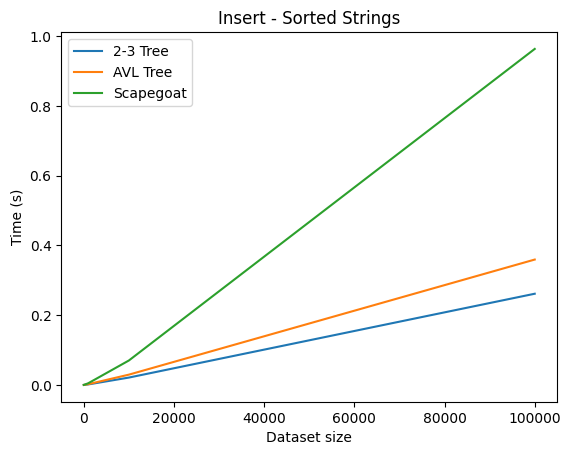

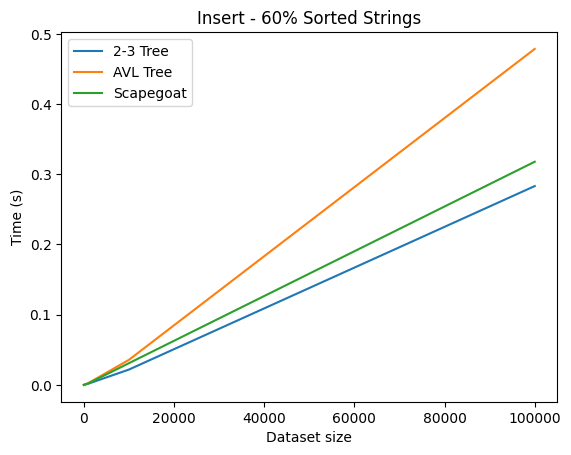

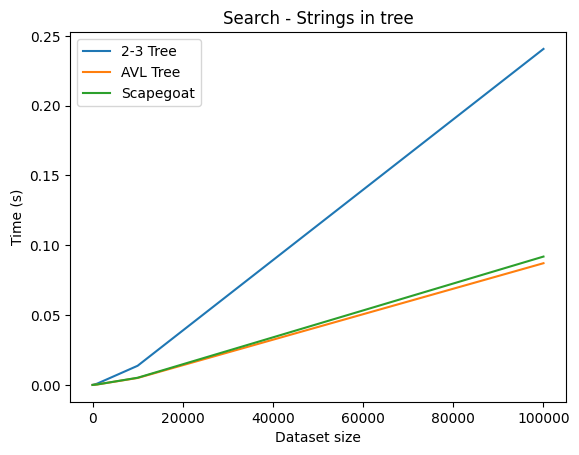

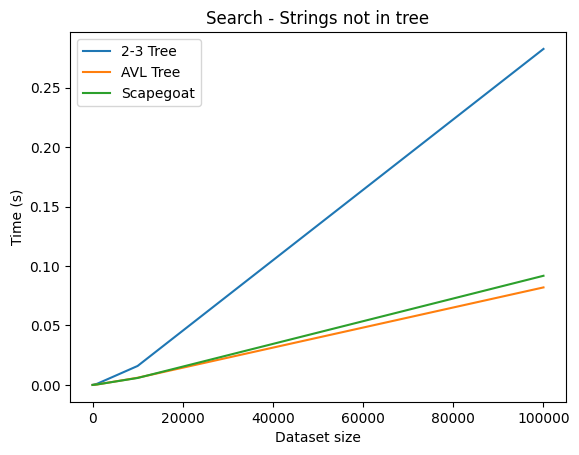

In [145]:
# ADD YOUR TEST CODE HERE 

framework = ExperimentalFramework()


# Tuples of (method name, grapgh title) for testing/plotting purposes
insert_data_generation = [(framework.data_generator.generate_random_strings, "Insert - Random Strings"),
                          (framework.data_generator.generate_strings_with_duplicates, "Insert - Duplicated Strings"),
                          (framework.data_generator.generate_sorted_strings, "Insert - Sorted Strings"),
                          (framework.data_generator.generate_nearly_sorted_strings, "Insert - 60% Sorted Strings")]

for method in insert_data_generation:
    results = {
        "2-3 Tree": framework.time_insert(TwoThreeTree, method[0]),
        "AVL Tree": framework.time_insert(AVLTree, method[0]),
        "Scapegoat": framework.time_insert(ScapegoatTree, method[0]),
    }
    framework.plot_comparison(results, method[1])

# Tuples of (method name, grapgh title) for testing/plotting purposes
search_data_generation = [(framework.data_generator.generate_search_hits, "Search - Strings in tree"),
                          (framework.data_generator.generate_search_misses, "Search - Strings not in tree")]

for method in search_data_generation:
    results = {
        "2-3 Tree": framework.time_search(TwoThreeTree, method[0]),
        "AVL Tree": framework.time_search(AVLTree, method[0]),
        "Scapegoat": framework.time_search(ScapegoatTree, method[0]),
    }
    framework.plot_comparison(results, method[1])